## 1) Création de l'entité initiale

On commence avec un catalogue de fichiers CSV qui contiennent les données de nos entreprises. On cherche à trouver, stocker et analyser les données des trois entreprises : **Google**, **Apple** et **SNCB** (numéros d'entreprises à renseigner).

### 🔍 Recherche — Google

In [25]:
from pathlib import Path
import pandas as pd

DATA = Path("KBO")

df_enterprise    = pd.read_csv(DATA / "enterprise.csv",    dtype=str)
df_denomination  = pd.read_csv(DATA / "denomination.csv",  dtype=str)
df_address       = pd.read_csv(DATA / "address.csv",       dtype=str)
df_activity      = pd.read_csv(DATA / "activity.csv",      dtype=str)
df_contact       = pd.read_csv(DATA / "contact.csv",       dtype=str)
df_establishment = pd.read_csv(DATA / "establishment.csv", dtype=str)
df_codes         = pd.read_csv(DATA / "code.csv",          dtype=str)

# Numéros BCE (format KBO Open Data : "XXXX.XXX.XXX")
GOOGLE_NUM = "0878.065.378"
APPLE_NUM  = "0836.157.420"
SNCB_NUM   = "0203.430.576"

print("Fichiers chargés.")
print(f"  enterprise    : {len(df_enterprise):>8,} lignes")
print(f"  denomination  : {len(df_denomination):>8,} lignes")
print(f"  address       : {len(df_address):>8,} lignes")
print(f"  activity      : {len(df_activity):>8,} lignes")
print(f"  contact       : {len(df_contact):>8,} lignes")
print(f"  establishment : {len(df_establishment):>8,} lignes")
print(f"  codes         : {len(df_codes):>8,} lignes")

Fichiers chargés.
  enterprise    : 1,951,671 lignes
  denomination  : 3,346,292 lignes
  address       : 2,881,017 lignes
  activity      : 34,510,460 lignes
  contact       :  706,353 lignes
  establishment : 1,687,516 lignes
  codes         :   21,468 lignes


In [26]:
def get_entity(numero: str) -> dict:
    """
    Retourne toutes les données brutes d'une entreprise issues des CSV KBO.
    Les codes ne sont PAS encore traduits — les valeurs brutes sont conservées.
    """
    # --- entreprise de base ---
    base = df_enterprise[df_enterprise["EnterpriseNumber"] == numero]

    # --- dénominations (toutes langues) ---
    denoms = df_denomination[df_denomination["EntityNumber"] == numero]
    # Priorité : TypeOfDenomination "001" (dénomination officielle) en FR (Language "1") puis NL ("2")
    nom_officiel = (
        denoms[denoms["TypeOfDenomination"] == "001"]
        .sort_values("Language")
        ["Denomination"]
        .iloc[0] if not denoms[denoms["TypeOfDenomination"] == "001"].empty else None
    )

    # --- adresse principale (REGO = siège social) ---
    addrs = df_address[df_address["EntityNumber"] == numero]
    siege = addrs[addrs["TypeOfAddress"] == "REGO"]
    if siege.empty:
        siege = addrs  # fallback : première adresse disponible
    adresse = siege.iloc[0] if not siege.empty else None

    # --- activités groupées par NaceVersion ---
    activites_raw = df_activity[df_activity["EntityNumber"] == numero]
    activites: dict[str, list] = {}
    for _, row in activites_raw.sort_values(["NaceVersion", "Classification"]).iterrows():
        version = row["NaceVersion"]
        if version not in activites:
            activites[version] = []
        activites[version].append({
            "ActivityGroup":  row["ActivityGroup"],
            "NaceCode":       row["NaceCode"],
            "Classification": row["Classification"],
        })

    # --- contacts ---
    contacts = df_contact[df_contact["EntityNumber"] == numero]
    tel   = contacts[contacts["ContactType"] == "TEL"]["Value"].tolist()
    email = contacts[contacts["ContactType"] == "EMAIL"]["Value"].tolist()
    web   = contacts[contacts["ContactType"] == "WEB"]["Value"].tolist()

    # --- établissements ---
    etabs = df_establishment[df_establishment["EnterpriseNumber"] == numero]

    return {
        "numero":          numero,
        "nom_officiel":    nom_officiel,
        "denominations":   denoms[["Language", "TypeOfDenomination", "Denomination"]].to_dict("records"),
        "enterprise":      base.iloc[0].to_dict() if not base.empty else {},
        "adresse":         adresse.to_dict() if adresse is not None else {},
        "activites":       activites,   # { "2025": [...], "2008": [...], ... }
        "telephone":       tel,
        "email":           email,
        "site_web":        web,
        "etablissements":  etabs[["EstablishmentNumber", "StartDate"]].to_dict("records"),
    }


def afficher_entity(e: dict):
    """Affiche un résumé lisible d'une entité."""
    print(f"{'='*60}")
    print(f"  {e['nom_officiel']}  ({e['numero']})")
    print(f"{'='*60}")

    ent = e["enterprise"]
    print(f"  Statut             : {ent.get('Status')}")
    print(f"  Situation juridique: {ent.get('JuridicalSituation')}")
    print(f"  Forme juridique    : {ent.get('JuridicalForm')}")
    print(f"  Type d'entreprise  : {ent.get('TypeOfEnterprise')}")
    print(f"  Date de création   : {ent.get('StartDate')}")

    adr = e["adresse"]
    rue = f"{adr.get('StreetFR') or adr.get('StreetNL', '')} {adr.get('HouseNumber', '')}".strip()
    ville = f"{adr.get('Zipcode', '')} {adr.get('MunicipalityFR') or adr.get('MunicipalityNL', '')}".strip()
    print(f"  Adresse            : {rue}, {ville}")

    total = sum(len(v) for v in e["activites"].values())
    print(f"  Activités")
    for version in sorted(e["activites"], reverse=True):
        print(f"    NACE {version} :")
        for act in e["activites"][version]:
            print(f"      {act['NaceCode']}  [{act['Classification']}]  groupe {act['ActivityGroup']}")
    print(f"  Téléphone          : {e['telephone']}")
    print(f"  Email              : {e['email']}")
    print(f"  Site web           : {e['site_web']}")
    print(f"  Etablissements     : {len(e['etablissements'])}")
    print()

    if e["denominations"]:
        print("  Dénominations :")
        df_d = pd.DataFrame(e["denominations"])
        print(df_d.to_string(index=False))
    print()

In [27]:
google = get_entity(GOOGLE_NUM)
afficher_entity(google)

  GOOGLE BELGIUM  (0878.065.378)
  Statut             : AC
  Situation juridique: 000
  Forme juridique    : 014
  Type d'entreprise  : 2
  Date de création   : 21-12-2005
  Adresse            : Chaussée d'Etterbeek 180, 1040 Bruxelles
  Activités
    NACE 2025 :
      73110  [MAIN]  groupe 006
      62900  [MAIN]  groupe 001
    NACE 2008 :
      73110  [MAIN]  groupe 006
      62090  [MAIN]  groupe 001
    NACE 2003 :
      74401  [MAIN]  groupe 006
      72600  [MAIN]  groupe 001
  Téléphone          : []
  Email              : []
  Site web           : []
  Etablissements     : 1

  Dénominations :
Language TypeOfDenomination   Denomination
       2                001 GOOGLE BELGIUM



### 🔍 Recherche — Apple

In [28]:
apple = get_entity(APPLE_NUM)
afficher_entity(apple)

  APPLE RETAIL BELGIUM  (0836.157.420)
  Statut             : AC
  Situation juridique: 000
  Forme juridique    : 610
  Type d'entreprise  : 2
  Date de création   : 06-05-2011
  Adresse            : Boulevard Saint-Lazare 4-10, 1210 Saint-Josse-ten-Noode
  Activités
    NACE 2025 :
      47400  [MAIN]  groupe 006
      47400  [MAIN]  groupe 001
    NACE 2008 :
      47410  [MAIN]  groupe 006
      47410  [MAIN]  groupe 001
  Téléphone          : []
  Email              : []
  Site web           : []
  Etablissements     : 2

  Dénominations :
Language TypeOfDenomination         Denomination
       2                001 APPLE RETAIL BELGIUM



### 🔍 Recherche — SNCB

In [29]:
sncb = get_entity(SNCB_NUM)
afficher_entity(sncb)

  SOCIÉTÉ NATIONALE DES CHEMINS DE FER BELGES  (0203.430.576)
  Statut             : AC
  Situation juridique: 000
  Forme juridique    : 114
  Type d'entreprise  : 2
  Date de création   : 01-01-1968
  Adresse            : Rue de France 56, 1060 Saint-Gilles
  Activités
    NACE 2025 :
      49110  [MAIN]  groupe 001
      80010  [SECO]  groupe 001
    NACE 2008 :
      49100  [MAIN]  groupe 001
      80100  [SECO]  groupe 001
    NACE 2003 :
      74601  [SECO]  groupe 001
  Téléphone          : []
  Email              : []
  Site web           : []
  Etablissements     : 270

  Dénominations :
Language TypeOfDenomination                                    Denomination
       1                001     SOCIÉTÉ NATIONALE DES CHEMINS DE FER BELGES
       1                002                                            SNCB
       2                001 NATIONALE MAATSCHAPPIJ DER BELGISCHE SPOORWEGEN
       2                002                                            NMBS



### 🔄 Traduction des codes CSV

On traduit maintenant les codes issus des fichiers CSV en valeurs lisibles (libellés, catégories, etc.).

In [30]:
# ---- Construction du dictionnaire de traduction ----
# Structure : { (Category, Code) : { Language: Description } }
CODE_LOOKUP: dict[tuple, dict] = {}

for _, row in df_codes.iterrows():
    key = (row["Category"], str(row["Code"]).strip())
    if key not in CODE_LOOKUP:
        CODE_LOOKUP[key] = {}
    CODE_LOOKUP[key][row["Language"]] = row["Description"]

print(f"Dictionnaire chargé : {len(CODE_LOOKUP)} entrées")
print(f"Catégories disponibles : {sorted({k[0] for k in CODE_LOOKUP})}")


def decode(category: str, code, lang: str = "FR") -> str:
    """
    Traduit un code brut en libellé lisible.

    Args:
        category : nom de la colonne source (ex. 'JuridicalForm', 'Status')
        code     : valeur brute du CSV (ex. '416', 'AC')
        lang     : 'FR' (défaut) ou 'NL'

    Returns:
        Libellé lisible, ou la valeur brute si introuvable.

    Exemples :
        decode('JuridicalForm', '416')         # -> 'Société à responsabilité limitée'
        decode('Status', 'AC')                 # -> 'Actif'
        decode('TypeOfAddress', 'REGO')        # -> 'Siège social'
        decode('JuridicalSituation', '000')    # -> 'Pas de situation particulière'
    """
    if code is None or (isinstance(code, float)):
        return None
    result = CODE_LOOKUP.get((category, str(code).strip()), {})
    return result.get(lang) or result.get("NL") or str(code)


# ---- Traduction d'une entité complète ----
def traduire_entity(e: dict, lang: str = "FR") -> dict:
    """
    Retourne une version traduite de l'entité —
    chaque code brut est remplacé par son libellé.
    """
    ent = e["enterprise"]
    adr = e["adresse"]

    # Choix du nom selon la langue
    lang_code = "1" if lang == "FR" else "2"
    noms = [d for d in e["denominations"] if d["Language"] == lang_code and d["TypeOfDenomination"] == "001"]
    nom = noms[0]["Denomination"] if noms else e["nom_officiel"]

    # Adresse traduite
    rue   = (adr.get("StreetFR") if lang == "FR" else adr.get("StreetNL")) or adr.get("StreetNL") or ""
    ville = (adr.get("MunicipalityFR") if lang == "FR" else adr.get("MunicipalityNL")) or ""

    # Activités : traduire ActivityGroup via code.csv
    # Activités groupées par NaceVersion, avec traduction complète
    # Le code NACE se résout via la catégorie "Nace{version}" (ex. "Nace2025")
    activites_tr: dict[str, list] = {}
    for version in sorted(e["activites"], reverse=True):
        activites_tr[version] = []
        for act in e["activites"][version]:
            activites_tr[version].append({
                "Classification": decode("Classification", act["Classification"],        lang),
                "Code NACE":      act["NaceCode"],
                "Description":    decode(f"Nace{version}", act["NaceCode"],             lang),
                "Groupe":         decode("ActivityGroup",  act["ActivityGroup"],         lang),
            })

    return {
        "Nom":                   nom,
        "Numéro BCE":            e["numero"],
        "Statut":                decode("Status",              ent.get("Status"),              lang),
        "Situation juridique":   decode("JuridicalSituation",  ent.get("JuridicalSituation"),  lang),
        "Forme juridique":       decode("JuridicalForm",       ent.get("JuridicalForm"),       lang),
        "Type d'entreprise":     decode("TypeOfEnterprise",    ent.get("TypeOfEnterprise"),    lang),
        "Date de création":      ent.get("StartDate"),
        "Adresse":               f"{rue} {adr.get('HouseNumber','')}, {adr.get('Zipcode','')} {ville}".strip(", "),
        "Type d'adresse":        decode("TypeOfAddress",       adr.get("TypeOfAddress"),       lang),
        "Activités":             activites_tr,
        "Téléphone":             e["telephone"],
        "Email":                 e["email"],
        "Site web":              e["site_web"],
        "Nb établissements":     len(e["etablissements"]),
    }

Dictionnaire chargé : 10641 entrées
Catégories disponibles : ['ActivityGroup', 'Classification', 'ContactType', 'EntityContact', 'JuridicalForm', 'JuridicalSituation', 'Language', 'Nace2003', 'Nace2008', 'Nace2025', 'Status', 'TypeOfAddress', 'TypeOfDenomination', 'TypeOfEnterprise']


In [31]:
for entite_raw in [google, apple, sncb]:
    t = traduire_entity(entite_raw)
    print(f"{'='*60}")
    print(f"  {t['Nom']}  ({t['Numéro BCE']})")
    print(f"{'='*60}")
    for k, v in t.items():
        if k == "Activités":
            total = sum(len(acts) for acts in v.values())
            print("Activités")
            for version in sorted(v, reverse=True):
                print(f"    NACE {version} :")
                for act in v[version]:
                    desc = act['Description'] or act['Code NACE']
                    print(f"      [{act['Classification']}]  {act['Code NACE']} — {desc}  ({act['Groupe']})")
        elif isinstance(v, list):
            print(f"  {k:<22}: {', '.join(v) if v else '—'}")
        else:
            print(f"  {k:<22}: {v or '—'}")
    print()


rows_tr = []
for entite_raw in [google, apple, sncb]:
    t = traduire_entity(entite_raw)
    nace_codes = ", ".join(a["Code NACE"] for acts in t["Activités"].values() for a in acts)
    rows_tr.append({
        "Entreprise":          t["Nom"],
        "Numéro BCE":          t["Numéro BCE"],
        "Statut":              t["Statut"],
        "Situation juridique": t["Situation juridique"],
        "Forme juridique":     t["Forme juridique"],
        "Type d'entreprise":   t["Type d'entreprise"],
        "Date de création":    t["Date de création"],
        "Codes NACE":          nace_codes,
        "Nb établissements":   t["Nb établissements"],
    })

df_tr = pd.DataFrame(rows_tr).set_index("Entreprise")
df_tr.T

  GOOGLE BELGIUM  (0878.065.378)
  Nom                   : GOOGLE BELGIUM
  Numéro BCE            : 0878.065.378
  Statut                : Actif
  Situation juridique   : Situation normale
  Forme juridique       : Société anonyme
  Type d'entreprise     : Personne morale
  Date de création      : 21-12-2005
  Adresse               : Chaussée d'Etterbeek 180, 1040 Bruxelles
  Type d'adresse        : Siège
Activités
    NACE 2025 :
      [Activité principale]  73110 — Activités d’agence de publicité  (Activités ONSS)
      [Activité principale]  62900 — Autres activités de service informatique  (Activités TVA)
    NACE 2008 :
      [Activité principale]  73110 — Activités des agences de publicité  (Activités ONSS)
      [Activité principale]  62090 — Autres activités informatiques  (Activités TVA)
    NACE 2003 :
      [Activité principale]  74401 — Agences de publicité  (Activités ONSS)
      [Activité principale]  72600 — Autres activités rattachées à l'informatique  (Activités TVA)
 

Entreprise,GOOGLE BELGIUM,APPLE RETAIL BELGIUM,SOCIÉTÉ NATIONALE DES CHEMINS DE FER BELGES
Numéro BCE,0878.065.378,0836.157.420,0203.430.576
Statut,Actif,Actif,Actif
Situation juridique,Situation normale,Situation normale,Situation normale
Forme juridique,Société anonyme,Société à responsabilité limitée,Société anonyme de droit public
Type d'entreprise,Personne morale,Personne morale,Personne morale
Date de création,21-12-2005,06-05-2011,01-01-1968
Codes NACE,"73110, 62900, 73110, 62090, 74401, 72600","47400, 47400, 47410, 47410","49110, 80010, 49100, 80100, 74601"
Nb établissements,1,2,270


In [32]:
## output after code transformations

---
## 2) Informations supplémentaires externes (KBO)

À partir d'ici, on récupère des données plus riches depuis le **Carrefour des Entreprises Belges (KBO/BCE)**.

URL de référence :  
`https://kbopub.economie.fgov.be/kbopub/toonondernemingps.html?ondernemingsnummer=<NUMERO>`

Exemple : https://kbopub.economie.fgov.be/kbopub/toonondernemingps.html?ondernemingsnummer=203430576

In [33]:
## Numéros d'entreprise (BCE)
# GOOGLE_NUM = "XXXXXXXXX"
# APPLE_NUM  = "XXXXXXXXX"
# SNCB_NUM   = "XXXXXXXXX"

BASE_URL = "https://kbopub.economie.fgov.be/kbopub/toonondernemingps.html"

## Scraping KBO pour chaque entreprise
# → récupérer le HTML de la page et parser les sections ci-dessous

In [34]:
import requests
from bs4 import BeautifulSoup

# Numéros d'entreprise (BCE) — sans points pour l'URL KBO
GOOGLE_NUM_URL = "878065378"
APPLE_NUM_URL  = "836157420"
SNCB_NUM_URL   = "203430576"

BASE_URL = "https://kbopub.economie.fgov.be/kbopub/toonondernemingps.html"

def get_kbo_page(numero: str) -> BeautifulSoup:
    """Télécharge et parse la fiche KBO d'une entreprise."""
    url = f"{BASE_URL}?lang=fr&ondernemingsnummer={numero}"
    headers = {"User-Agent": "Mozilla/5.0", "Accept-Language": "fr-BE,fr;q=0.9"}
    resp = requests.get(url, headers=headers, timeout=15)
    resp.raise_for_status()
    return BeautifulSoup(resp.text, "lxml")

---
### 2.1) Informations Générales

| Champ | Valeur |
|---|---|
| Dénomination | |
| Numéro d'entreprise | |
| Adresse | |
| Activité principale | |
| Effectif | |
| Date de création | |

In [35]:
## Extraction — Informations Générales
# denomination     = ...
# numero           = ...
# adresse          = ...
# activite_principale = ...
# effectif         = ...
# date_creation    = ...


---
### 2.2) Informations Juridiques

| Champ | Valeur |
|---|---|
| Numéro | |
| SIRET | |
| Forme juridique | |
| Numéro de TVA | |
| EUD | |
| Situation juridique | |
| Capital social | |
| Assemblée générale | |
| Date de fin de l'année comptable | |

In [36]:
## Extraction — Informations Juridiques
# numero_juridique    = ...
# siret               = ...
# forme_juridique     = ...
# numero_tva          = ...
# eud                 = ...
# situation_juridique = ...
# capital_social      = ...
# assemblee_generale  = ...
# fin_annee_comptable = ...

---
### 2.3) Activités

Liste de chaque domaine d'activité avec son code NACE/ONSS.

| Code | Description |
|---|---|

In [37]:
## Extraction — Activités
# activites = [
#   {"code": "XXXXX", "description": "..."},
#   ...
# ]

---
### 2.4) Dirigeants et Représentants

Liste de chaque dirigeant avec sa ou ses qualité(s).

| Nom | Qualité(s) |
|---|---|

In [38]:
## Extraction — Dirigeants
# dirigeants = [
#   {"nom": "...", "qualites": ["...", "..."]},
#   ...
# ]

---
### 2.5) Liens entre Entités

Liste de chaque entité liée à l'entreprise.

| Entité | Numéro d'entreprise | Date du lien | Nature du lien | Statut actuel |
|---|---|---|---|---|

In [39]:
## Extraction — Liens entre entités
# liens = [
#   {
#     "entite": "...",
#     "numero": "...",
#     "date_lien": "...",
#     "nature": "...",
#     "statut": "..."
#   },
#   ...
# ]

---
### 2.6) Documents Juridiques (Statuts)

Source : https://statuts.notaire.be/stapor_v1/enterprise/{numero}/statutes

| Document | Date | Lien |
|---|---|---|

In [40]:
# ── Section 2.6 : Statuts notaire ──────────────────────────────────────────
import logging, time, requests


ENTREPRISES = {
    "Google Belgium":       "0878065378",
    "Apple Retail Belgium": "0836157420",
    "SNCB":                 "0203430576",
}
log = logging.getLogger(__name__)

BASE_NOTAIRE = "https://statuts.notaire.be/stapor_v1"
TMP_NOTAIRE  = Path("tmp/notaire")
TMP_NOTAIRE.mkdir(parents=True, exist_ok=True)

HEADERS_NOTAIRE = {
    "User-Agent":      "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/136.0.0.0 Safari/537.36",
    "Accept":          "application/json, text/plain, */*",
    "sec-fetch-dest":  "empty",
    "sec-fetch-mode":  "cors",
    "sec-fetch-site":  "same-origin",
}

# Coller ici les cookies copiés depuis Chrome (Network tab → cookie:)
# Les remplacer quand ils expirent (~1h)
BROWSER_COOKIES = (
    "_gid=GA1.2.976204352.1782727762; TS01dc4fc6=01b8f84c...; OClmoOot=A7BOQ...; Lyp1CWKh=A1VqOR..."
)

def notaire_session(cookie_header: str) -> requests.Session:
    session = requests.Session()
    session.headers.update(HEADERS_NOTAIRE)
    for part in cookie_header.split(";"):
        if "=" in part:
            name, _, value = part.strip().partition("=")
            session.cookies.set(name.strip(), value.strip(), domain="statuts.notaire.be")
    return session

def get_statutes(session, enterprise_number: str) -> list[dict]:
    url = f"{BASE_NOTAIRE}/api/enterprises/{enterprise_number}/statutes"
    session.headers["Referer"] = f"{BASE_NOTAIRE}/enterprise/{enterprise_number}/statutes?enterpriseNumber={enterprise_number}&statuteStart=0&statuteCount=5"
    all_statutes, offset = [], 0
    while True:
        r = session.get(url, params={"deedDate": "", "offset": offset, "limit": 20}, timeout=15)
        if "application/json" not in r.headers.get("content-type", ""):
            print("Session expirée — recoller BROWSER_COOKIES")
            break
        data = r.json()
        batch = data.get("statutes", [])
        all_statutes.extend(batch)
        if not batch or len(all_statutes) >= data.get("totalItems", 0):
            break
        offset += 20
        time.sleep(0.3)
    return [s for s in all_statutes if s.get("documentStatus") == "DONE"]

def download_statute_pdf(session, enterprise_number: str, statute: dict) -> Path | None:
    doc_id    = statute["documentId"]
    deed_date = statute.get("deedDate", "unknown").replace("-", "")
    dest      = TMP_NOTAIRE / f"{enterprise_number}_{deed_date}_{doc_id}.pdf"
    if dest.exists():
        return dest
    r = session.get(f"{BASE_NOTAIRE}/api/enterprises/{enterprise_number}/statutes/non-certified/{doc_id}", timeout=30)
    if r.status_code == 404 or "pdf" not in r.headers.get("content-type", ""):
        return None
    dest.write_bytes(r.content)
    print(f"    Sauvegardé : {dest.name} ({len(r.content)//1024} KB)")
    return dest

# Run
notaire_ses = notaire_session(BROWSER_COOKIES)
statuts_par_entreprise = {}

for nom, numero in ENTREPRISES.items():
    bce_clean = numero.replace(".", "")
    statutes  = get_statutes(notaire_ses, bce_clean)
    results   = []
    for s in statutes:
        pdf = download_statute_pdf(notaire_ses, bce_clean, s)
        results.append({**s, "local_pdf": str(pdf) if pdf else None})
        time.sleep(0.3)
    statuts_par_entreprise[nom] = results
    print(f"{nom} : {len(results)} statuts")

Session expirée — recoller BROWSER_COOKIES
Google Belgium : 0 statuts
Session expirée — recoller BROWSER_COOKIES
Apple Retail Belgium : 0 statuts
Session expirée — recoller BROWSER_COOKIES
SNCB : 0 statuts


---
### 2.7) Comptes Annuels

Source : https://consult.cbso.nbb.be/consult-enterprise/{numero}

Pagination et téléchargement de tous les documents avec date de publication et année fiscale concernée.

| Année fiscale | Date de publication | Document |
|---|---|---|

In [41]:
import time, requests
from pathlib import Path

TMP = Path("tmp/pdfs")
TMP.mkdir(parents=True, exist_ok=True)

BASE    = "https://consult.cbso.nbb.be/api"
HEADERS = {
    "User-Agent":     "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/149.0.0.0 Safari/537.36",
    "Accept":         "application/json, text/plain, */*",
    "sec-fetch-dest": "empty",
    "sec-fetch-mode": "cors",
    "sec-fetch-site": "same-origin",
}

def get_deposits(numero: str) -> list:
    session = requests.Session()
    session.headers.update(HEADERS)
    session.headers["Referer"] = f"https://consult.cbso.nbb.be/consult-enterprise/{numero}"
    r = session.get(f"{BASE}/rs-consult/published-deposits?page=0&size=50&enterpriseNumber={numero}&sort=periodEndDate,desc")
    return r.json()["content"]

def download_pdf(numero: str, deposit: dict) -> Path:
    session = requests.Session()
    session.headers.update(HEADERS)
    dest = TMP / f"{numero}_{deposit['periodEndDateYear']}_{deposit['reference']}.pdf"
    if dest.exists():
        return dest
    r = session.get(f"{BASE}/external/broker/public/deposits/pdf/{deposit['id']}")
    dest.write_bytes(r.content)
    print(f"  {dest.name} ({len(r.content)//1024} KB)")
    return dest

# Run
for nom, numero in ENTREPRISES.items():
    print(f"\n{nom}")
    for dep in get_deposits(numero):
        download_pdf(numero, dep)
        time.sleep(0.3)


Google Belgium

Apple Retail Belgium

SNCB


---
### 2.8) Établissements

Liste de chaque établissement de l'entreprise.

| Numéro | Adresse | Date de création | Activité |
|---|---|---|---|

In [42]:
## Extraction — Établissements
# etablissements = [
#   {
#     "numero": "...",
#     "adresse": "...",
#     "date_creation": "...",
#     "activite": "..."
#   },
#   ...
# ]

---
### 2.9) Publications (eJustice)

Source : https://www.ejustice.just.fgov.be/cgi_tsv/list.pl?language=fr&btw={tva}&page=1

| Date | Référence (NUMAC) | Type | Lien |
|---|---|---|---|

In [43]:
## Extraction — Publications eJustice
# EJUSTICE_URL = f"https://www.ejustice.just.fgov.be/cgi_tsv/list.pl?language=fr&btw={numero_tva}&page=1"
# → paginer toutes les pages
# → pour chaque publication : date, numac, type, lien

---
### 2.10) Informations de Contact

| Champ | Valeur |
|---|---|
| Téléphone | |
| Email | |
| Site web | |
| Adresse | |

In [44]:
## Extraction — Informations de Contact
# telephone = ...
# email     = ...
# site_web  = ...
# adresse   = ...

---
## 3) Finances

Tableau financier depuis 2021 (ou depuis la création) jusqu'à 2025, enrichi avec l'EBIT.

### 📊 Tableau des indicateurs financiers

#### Performance
| Indicateur | 2021 | 2022 | 2023 | 2024 | 2025 |
|---|---|---|---|---|---|
| Chiffre d'affaires | | | | | |
| Marge brute | | | | | |
| EBIT (Résultat d'exploitation) | | | | | |
| Résultat net | | | | | |

#### Croissance
| Indicateur | 2021 | 2022 | 2023 | 2024 | 2025 |
|---|---|---|---|---|---|
| Taux de croissance du CA (%) | | | | | |
| Taux de marge brute (%) | | | | | |
| % de marge nette | | | | | |

#### Autonomie Financière
| Indicateur | 2021 | 2022 | 2023 | 2024 | 2025 |
|---|---|---|---|---|---|
| Trésorerie | | | | | |
| Dettes financières | | | | | |
| Dette financière nette | | | | | |

#### Solvabilité
| Indicateur | 2021 | 2022 | 2023 | 2024 | 2025 |
|---|---|---|---|---|---|
| Fonds propres | | | | | |

#### Ressources Humaines & Coûts
| Indicateur | 2021 | 2022 | 2023 | 2024 | 2025 |
|---|---|---|---|---|---|
| Nombre d'employés | | | | | |
| Coûts salariaux (salaires + charges + avantages) | | | | | |
| Employés en % du coût des revenus | | | | | |
| Revenu par employé | | | | | |
| Taxes payées | | | | | |

In [45]:
import time
import requests
import pandas as pd
from io import StringIO
from pathlib import Path

TMP = Path("tmp/pdfs")
TMP.mkdir(parents=True, exist_ok=True)

BASE = "https://consult.cbso.nbb.be/api"

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/149.0.0.0 Safari/537.36",
    "Accept": "application/json, text/plain, */*",
    "Accept-Language": "en-US,en;q=0.9",
    "sec-fetch-dest": "empty",
    "sec-fetch-mode": "cors",
    "sec-fetch-site": "same-origin",
}


def make_session(enterprise_number: str) -> requests.Session:
    session = requests.Session()
    session.headers.update(HEADERS)
    page_url = f"https://consult.cbso.nbb.be/consult-enterprise/{enterprise_number}"
    session.headers.update({"Referer": page_url})
    session.get(page_url)  # establishes ASLBSA, ASLBSACORS, JSESSIONID cookies
    return session


def get_deposits(session: requests.Session, enterprise_number: str) -> list:
    url = (
        f"{BASE}/rs-consult/published-deposits"
        f"?page=0&size=50&enterpriseNumber={enterprise_number}"
        f"&sort=periodEndDate,desc&sort=depositDate,desc"
    )
    r = session.get(url)
    r.raise_for_status()
    data = r.json()

    # Un seul dépôt par année : skip consolidés (mc-*), préférer FR sur NL
    seen: dict[int, dict] = {}
    for d in data["content"]:
        if (d.get("modelCode") or "").startswith("mc"):
            continue
        year = d["periodEndDateYear"]
        lang = (d.get("language") or "").upper()
        if year not in seen or lang == "FR":
            seen[year] = d

    return sorted(seen.values(), key=lambda d: d["periodEndDateYear"], reverse=True)


def download_csv(session: requests.Session, deposit_id: str) -> str:
    url = f"{BASE}/external/broker/public/deposits/consult/csv/{deposit_id}"
    r = session.get(url)
    r.raise_for_status()
    return r.text


def download_pdf(session: requests.Session, deposit: dict) -> Path:
    """Download PDF for a deposit and save to tmp/pdfs/. Returns the saved path."""
    deposit_id  = deposit["id"]
    year        = deposit["periodEndDateYear"]
    enterprise  = deposit["enterpriseNumber"]
    reference   = deposit["reference"]
    filename    = f"{enterprise}_{year}_{reference}.pdf"
    dest        = TMP / filename

    if dest.exists():
        print(f"    PDF already exists: {filename}")
        return dest

    url = f"{BASE}/external/broker/public/deposits/pdf/{deposit_id}"
    r = session.get(url)
    r.raise_for_status()
    dest.write_bytes(r.content)
    print(f"    PDF saved: {filename} ({len(r.content) // 1024} KB)")
    return dest


def parse_csv(csv_text: str) -> dict:
    df = pd.read_csv(StringIO(csv_text), header=None, skiprows=1)
    codes = {}
    for _, row in df.iterrows():
        key = str(row[0]).strip()
        try:
            codes[key] = float(row[1])
        except (ValueError, TypeError):
            codes[key] = row[1]
    return codes


def compute_kpis(codes: dict) -> dict:
    def get(code):
        return codes.get(code, 0.0)

    omzet        = get("70")
    cogs         = get("60")
    depreciation = get("630")
    ebit         = get("9901")
    net_profit   = get("9904")
    cash         = get("54/58")
    equity       = get("10/15")
    total_assets = get("20/58")
    fin_debt     = get("17") + get("43")
    gross_profit = omzet - cogs
    ebitda       = ebit + depreciation

    def pct(num, denom):
        return round(num / denom * 100, 2) if denom else None

    return {
        "entity":           codes.get("Entity name"),
        "period_end":       codes.get("Accounting period end date"),
        "chiffre_affaires": omzet,
        "marge_brute":      gross_profit,
        "ebitda":           ebitda,
        "ebit":             ebit,
        "resultat_net":     net_profit,
        "taux_marge_brute": pct(gross_profit, omzet),
        "taux_ebitda":      pct(ebitda, omzet),
        "marge_nette":      pct(net_profit, omzet),
        "tresorerie":       cash,
        "dettes_fin":       fin_debt,
        "dette_nette":      fin_debt - cash,
        "fonds_propres":    equity,
        "total_actif":      total_assets,
        "autonomie_fin":    pct(equity, total_assets),
    }


def get_all_kpis(enterprise_number: str) -> list[dict]:
    session = make_session(enterprise_number)
    deposits = get_deposits(session, enterprise_number)

    results = []
    for deposit in deposits:
        deposit_id = deposit["id"]
        year = deposit["periodEndDateYear"]

        print(f"  Processing {year} (id={deposit_id})...")

        # Always attempt PDF download (works for all years including migrated)
        try:
            download_pdf(session, deposit)
        except Exception as e:
            print(f"    ✗ PDF failed for {year}: {e}")
        time.sleep(0.3)

        # CSV only available for non-migrated filings
        if deposit.get("migration"):
            print(f"    Skipping CSV for {year} (legacy/migrated filing)")
            continue

        try:
            csv_text = download_csv(session, deposit_id)
            codes = parse_csv(csv_text)
            kpis = compute_kpis(codes)
            kpis["year"] = year
            kpis["reference"] = deposit["reference"]
            results.append(kpis)
        except Exception as e:
            print(f"    ✗ CSV failed for {year}: {e}")
        time.sleep(0.3)

    return results


# --- Run ---
ENTREPRISES = {
    "Google Belgium":       "0878065378",
}

all_kpis = {}
for nom, numero in ENTREPRISES.items():
    kpis = get_all_kpis(numero)
    all_kpis[nom] = pd.DataFrame(kpis).set_index("year").sort_index()

  Processing 2025 (id=d484206e-64d0-11f1-9ec1-cd09be5c3704)...
    PDF already exists: 0878065378_2025_2026-00149705.pdf
  Processing 2024 (id=fc466e19-51c0-11f0-91d9-ed2f935a55bb)...
    PDF already exists: 0878065378_2024_2025-00184871.pdf
  Processing 2023 (id=95d1b903-3aac-11ef-bac7-552a28bb81e5)...
    PDF already exists: 0878065378_2023_2024-00218430.pdf
  Processing 2022 (id=2815da05-1f1c-11ee-9448-dd0543d924d2)...
    PDF already exists: 0878065378_2022_2023-00223819.pdf
  Processing 2021 (id=954e6e68-fd0d-11ec-b54f-f1ace43687a0)...
    PDF already exists: 0878065378_2021_2022-20180306.pdf
  Processing 2020 (id=A8DD251A-049E-4D37-93A3-B56B69344CB5)...
    PDF already exists: 0878065378_2020_2021-39600206.pdf
    Skipping CSV for 2020 (legacy/migrated filing)
  Processing 2019 (id=DB866F19-D1B5-45E6-AFB6-15CB2EAD0D98)...
    PDF already exists: 0878065378_2019_2020-58600234.pdf
    Skipping CSV for 2019 (legacy/migrated filing)
  Processing 2018 (id=5352025D-BB58-4E02-B659-C96EC

In [46]:
pd.set_option("display.max_columns", None)

eur_cols = ["chiffre_affaires", "marge_brute", "ebitda", "resultat_net",
            "tresorerie", "dettes_fin", "dette_nette", "fonds_propres"]
pct_cols = ["taux_marge_brute", "taux_ebitda", "marge_nette", "autonomie_fin"]
cols     = eur_cols + pct_cols

for nom, df in all_kpis.items():
    print(f"\n{'='*60}\n  {nom}\n{'='*60}")
    disp = df[cols].copy()
    for c in eur_cols:
        disp[c] = disp[c].apply(lambda x: f"{x:,.0f}" if pd.notna(x) else "-")
    for c in pct_cols:
        disp[c] = disp[c].apply(lambda x: f"{x:.1f}%" if pd.notna(x) else "-")
    print(disp.to_string())


  Google Belgium
     chiffre_affaires marge_brute      ebitda resultat_net tresorerie dettes_fin dette_nette fonds_propres taux_marge_brute taux_ebitda marge_nette autonomie_fin
year                                                                                                                                                             
2021       63,066,577  63,066,577  10,155,360    6,529,995          0          0           0    30,438,332           100.0%       16.1%       10.3%         60.1%
2022       77,386,505  77,386,505  14,155,232    9,532,020          0          0           0    39,970,352           100.0%       18.3%       12.3%         61.4%
2023       94,095,721  94,095,721  16,530,148   12,471,274          0          0           0    52,441,626           100.0%       17.6%       13.2%         66.7%
2024       92,512,761  92,512,761  16,373,468   12,985,558          0          0           0    65,427,185           100.0%       17.7%       14.0%         76.5%
2025      

In [47]:
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "notebook"

def sankey_entreprise(filing, nom: str, year: int):
    def g(code): return filing.get(code) or 0.0

    ca   = g("70")
    cogs = g("60")
    gp   = ca - cogs
    ebit = g("9901")
    opex = max(gp - ebit, 0)
    tax  = g("670/3")
    net  = g("9904")
    ebt  = net + tax

    fmt = lambda x: f"{x/1e6:.1f}M €" if abs(x) >= 1e6 else f"{x:,.0f} €"
    has_cogs = cogs > ca * 0.01   # skip COGS node if negligible

    if has_cogs:
        labels = [
            f"Chiffre d'affaires {fmt(ca)}",        # 0
            f"Marge brute {fmt(gp)}",                # 1
            f"Coût des ventes {fmt(cogs)}",          # 2
            f"Résultat exploit. {fmt(ebit)}",        # 3
            f"Charges exploit. {fmt(opex)}",         # 4
            f"Résultat avant impôts {fmt(ebt)}",     # 5
            f"Résultat net {fmt(net)}",              # 6
            f"Impôts {fmt(tax)}",                    # 7
        ]
        xs = [0.01, 0.28, 0.28, 0.58, 0.58, 0.78, 0.99, 0.99]
        ys = [0.30, 0.10, 0.80, 0.05, 0.75, 0.05, 0.02, 0.55]
        colors = ["#888","#2ca02c","#d62728","#2ca02c","#d62728","#2ca02c","#1f77b4","#d62728"]
        links = [
            (0, 1, gp,   "rgba(44,160,44,0.4)"),
            (0, 2, cogs, "rgba(214,39,40,0.3)"),
            (1, 3, ebit, "rgba(44,160,44,0.4)"),
            (1, 4, opex, "rgba(214,39,40,0.3)"),
            (3, 5, ebt,  "rgba(44,160,44,0.4)"),
            (5, 6, net,  "rgba(44,160,44,0.4)"),
            (5, 7, tax,  "rgba(214,39,40,0.3)"),
        ]
    else:
        # Société de services : pas de COGS, aller direct CA → EBIT + charges
        labels = [
            f"Chiffre d'affaires {fmt(ca)}",        # 0
            f"Résultat exploit. {fmt(ebit)}",        # 1
            f"Charges exploit. {fmt(opex)}",         # 2
            f"Résultat avant impôts {fmt(ebt)}",     # 3
            f"Résultat net {fmt(net)}",              # 4
            f"Impôts {fmt(tax)}",                    # 5
        ]
        xs = [0.01, 0.45, 0.45, 0.75, 0.99, 0.99]
        ys = [0.25, 0.05, 0.70, 0.05, 0.02, 0.55]
        colors = ["#888","#2ca02c","#d62728","#2ca02c","#1f77b4","#d62728"]
        links = [
            (0, 1, ebit, "rgba(44,160,44,0.4)"),
            (0, 2, opex, "rgba(214,39,40,0.3)"),
            (1, 3, ebt,  "rgba(44,160,44,0.4)"),
            (3, 4, net,  "rgba(44,160,44,0.4)"),
            (3, 5, tax,  "rgba(214,39,40,0.3)"),
        ]

    src, tgt, val, col = zip(*links)

    fig = go.Figure(go.Sankey(
        arrangement="snap",
        node=dict(pad=12, thickness=20, label=labels, color=colors, x=xs, y=ys),
        link=dict(source=src, target=tgt, value=val, color=col),
    ))
    fig.update_layout(
        title=dict(text=f"{nom} — Compte de résultats {year}", font_size=15),
        height=500, font_size=11,
    )
    fig.show()

for nom, numero in ENTREPRISES.items():
    session = make_session(numero)
    deps = get_deposits(session, numero)
    latest = next((d for d in deps if not d.get("migration")), None)
    if latest:
        raw = download_csv(session, latest["id"])
        from nbb import Filing
        f = Filing(raw)
        sankey_entreprise(f, nom, latest["periodEndDateYear"])

ModuleNotFoundError: No module named 'nbb'

---
### 📈 Graphiques — Chiffre d'affaires & Résultat net (2021–2025)

In [ ]:
print(df_finances.columns.tolist())

NameError: name 'df_finances' is not defined

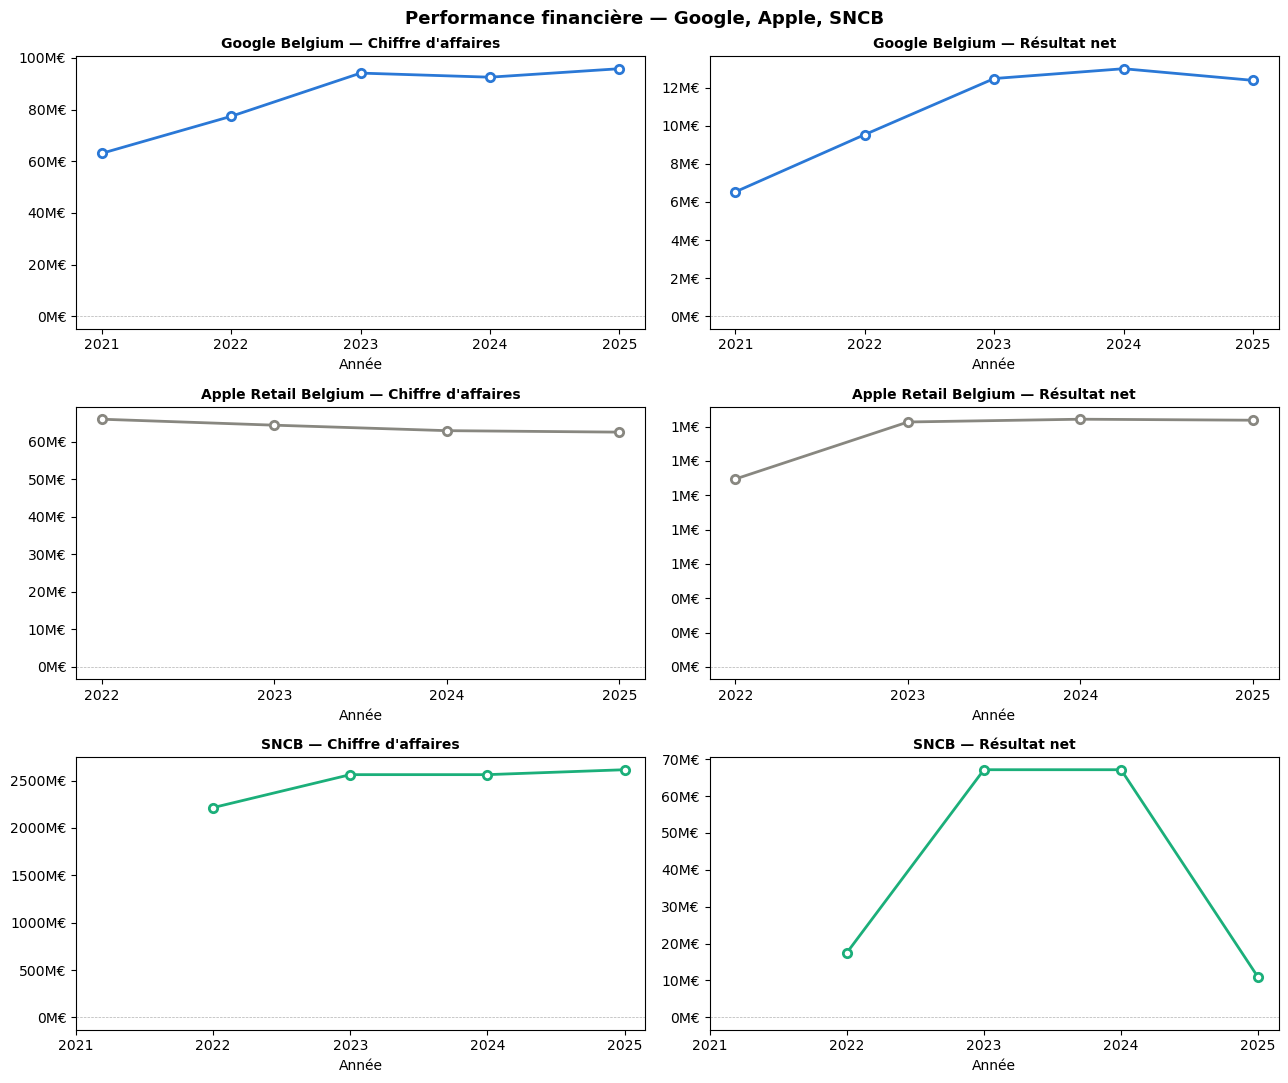

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

companies = list(all_kpis.keys())
colors = {"Google Belgium": "#2a78d6", "Apple Retail Belgium": "#888780", "SNCB": "#1baf7a"}

fig, axes = plt.subplots(3, 2, figsize=(13, 11))
fig.suptitle("Performance financière — Google, Apple, SNCB", fontsize=13, fontweight="bold")

for i, nom in enumerate(companies):
    df = all_kpis[nom].copy().replace(0, float("nan")).ffill()
    color = colors[nom]
    years = df.index.tolist()

    for j, (col, title) in enumerate([("chiffre_affaires", "Chiffre d'affaires"), ("resultat_net", "Résultat net")]):
        ax = axes[i][j]
        ax.plot(years, df[col], marker="o", linewidth=2, color=color,
                markerfacecolor="white", markeredgewidth=2)
        ax.set_title(f"{nom} — {title}", fontsize=10, fontweight="bold")
        ax.set_xticks(years)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x)}"))
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x, _: f"{x/1e9:.1f}Mrd€" if max(abs(df[col].dropna())) >= 1e9
                         else f"{x/1e6:.0f}M€"
        ))
        ax.axhline(0, color="black", linewidth=0.5, linestyle="--", alpha=0.3)
        ax.set_xlabel("Année")

fig.tight_layout()
plt.show()